In [1]:
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
from hb_conv import HbConvert
from process_models import FOPDT
from scipy.signal import butter, filtfilt
from data_objects import Experiment, Event
import pickle

Trimming indices for each animal

1. Aim - 150:end
2. Blitz - 50:end
3. Cascade - 30:5100
4. DidiSeven - 50:end
5. EcoFresh - 50:end

In [14]:
filename = 'Cascade_HYP_1to2_MAP_aligned.csv'
filepath = f'/Users/hussain/Desktop/pynirs_project/data/aligned-nirs/aligned/{filename}'

rate = 1
e_raw = Experiment(filepath, rate)
start_idx = int(50 * rate) ## change according to the reference above
end_idx = int(5100 * rate)
e_raw.data = e_raw.data.iloc[start_idx:end_idx].reset_index(drop=True) ## uncomment this only for Cascade
#e_raw.data = e_raw.data.iloc[start_idx:].reset_index(drop=True) ## uncomment this for all the animals except Cascade

cutoff = 1/300
e_raw.butter(order=4, wn=cutoff, fs=rate, btype='lowpass')
e_raw.filter()

Instantiating Experiment object
Loading /Users/hussain/Desktop/pynirs_project/data/aligned-nirs/aligned/Cascade_HYP_1to2_MAP_aligned.csv
Index(['Timestamps', 'ABP', 'SBP', 'DBP', 'PP', 'MAP', 'HR(abp)', 'SpO2',
       'HR(nonin)', 'NKY(68)', 'NKY(69)', 'TX1_O2Hb', 'TX1_HHb', 'TX1_tHb',
       'TX1_HbD', 'TX2_O2Hb', 'TX2_HHb', 'TX2_tHb', 'TX2_HbD', 'TX3_O2Hb',
       'TX3_HHb', 'TX3_tHb', 'TX3_HbD', 'TSI', 'TSI_FitFactor', 'Portasync',
       'RDNIRS_Amb_Corr_Near_LED1', 'RDNIRS_Amb_Corr_Near_LED2',
       'RDNIRS_Amb_Corr_Near_LED3', 'RDNIRS_Amb_Corr_Near_LED4',
       'RDNIRS_Amb_Corr_Near_LED5', 'RDNIRS_Amb_Near',
       'RDNIRS_Amb_Corr_Far_LED1', 'RDNIRS_Amb_Corr_Far_LED2',
       'RDNIRS_Amb_Corr_Far_LED3', 'RDNIRS_Amb_Corr_Far_LED4',
       'RDNIRS_Amb_Corr_Far_LED5', 'RDNIRS_Amb_Far', 'RDNIRS_Accelerometer_1',
       'RDNIRS_Accelerometer_2', 'RDNIRS_Accelerometer_3', 'DNIRS_R_Near_O2Hb',
       'DNIRS_R_Near_HHb', 'DNIRS_R_Near_tHb', 'DNIRS_R_Near_HbD',
       'DNIRS_R_Far_O2Hb

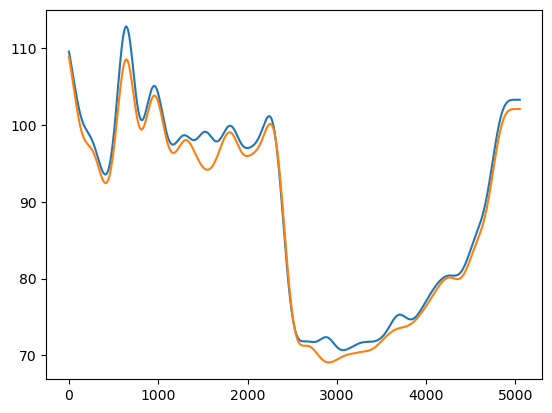

In [15]:
plt.plot(e_raw.data["HR(abp)"])
plt.plot(e_raw.data["HR(nonin)"])

Absorbance channel indices per animal

1. Aim, Blitz, Cascade - Caudal -> [49:61], Rostral -> [25:37]
2. DidiSeven - Caudal -> [10:22], Rostral -> [50:62]
3. EcoFresh - Caudal -> [34:46], Rostral -> [12:24]

In [16]:
e_raw.data.columns[25:37] ## to confirm the correct indexing of the absorbance channels

Index(['RDNIRS_Amb_Corr_Near_LED1', 'RDNIRS_Amb_Corr_Near_LED2',
       'RDNIRS_Amb_Corr_Near_LED3', 'RDNIRS_Amb_Corr_Near_LED4',
       'RDNIRS_Amb_Corr_Near_LED5', 'RDNIRS_Amb_Near',
       'RDNIRS_Amb_Corr_Far_LED1', 'RDNIRS_Amb_Corr_Far_LED2',
       'RDNIRS_Amb_Corr_Far_LED3', 'RDNIRS_Amb_Corr_Far_LED4',
       'RDNIRS_Amb_Corr_Far_LED5', 'RDNIRS_Amb_Far'],
      dtype='object')

In [17]:
e_raw.data.columns[49:61] ## to confirm the correct indexing of the absorbance channels

Index(['CDNIRS_Amb_Corr_Near_LED1', 'CDNIRS_Amb_Corr_Near_LED2',
       'CDNIRS_Amb_Corr_Near_LED3', 'CDNIRS_Amb_Corr_Near_LED4',
       'CDNIRS_Amb_Corr_Near_LED5', 'CDNIRS_Amb_Near',
       'CDNIRS_Amb_Corr_Far_LED1', 'CDNIRS_Amb_Corr_Far_LED2',
       'CDNIRS_Amb_Corr_Far_LED3', 'CDNIRS_Amb_Corr_Far_LED4',
       'CDNIRS_Amb_Corr_Far_LED5', 'CDNIRS_Amb_Far'],
      dtype='object')

In [18]:
pd_reads_C = e_raw.data.iloc[:, 49:61]
pd_reads_R = e_raw.data.iloc[:, 25:37]

pd_reads_C = pd_reads_C.to_numpy().T
hb_C = HbConvert(pd_reads_C)

pd_reads_R = pd_reads_R.to_numpy().T
hb_R = HbConvert(pd_reads_R)

"all_extracted_event_summaries.csv" contains information about the challenges associated with each file.

In [19]:
summaries_df = pd.read_csv("/Users/hussain/Desktop/pynirs_project/data/all_extracted_event_summaries.csv")
events = summaries_df[summaries_df["source"]==filename]
print(events)

index = 3 ## refers to the challenge from the list below (starts at index 0)

pre, post = 300, 300

row = events.iloc[index]
challenge_name = events.iloc[index][0]
start = events.iloc[index][1]
stop = events.iloc[index][2]

    challenge  start   end  duration                            source
12  hypoxia 1    172   229        58  Cascade_HYP_1to2_MAP_aligned.csv
13  hypoxia 2    395   449        55  Cascade_HYP_1to2_MAP_aligned.csv
14        BSL    613  1492       880  Cascade_HYP_1to2_MAP_aligned.csv
15         NE   1800  4819      3020  Cascade_HYP_1to2_MAP_aligned.csv


/var/folders/xg/4v7ggv592ks888b789wqsvh80000gn/T/ipykernel_78770/2448837909.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  challenge_name = events.iloc[index][0]
/var/folders/xg/4v7ggv592ks888b789wqsvh80000gn/T/ipykernel_78770/2448837909.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start = events.iloc[index][1]
/var/folders/xg/4v7ggv592ks888b789wqsvh80000gn/T/ipykernel_78770/2448837909.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, us

Index 0 corresponds to O2hb
Index 1 corresponds to Hhb
Index 2 corresponds to thb

In [20]:
event_data = e_raw.data

cleaned_cnear_O2hb = hb_R.cleaned.hbc_near[0][start - pre : stop + post]
cleaned_cnear_O2hb -= cleaned_cnear_O2hb[0]

observed_cnear_O2hb = hb_R.observed.hbc_near[0][start - pre : stop + post]
observed_cnear_O2hb -= observed_cnear_O2hb[0]

MAP = event_data["MAP"][start - pre : stop + post].to_numpy()
MAP -= MAP[0]

HR = event_data["HR(abp)"][start - pre : stop + post].to_numpy()
HR -= HR[0]

t = np.arange(len(MAP)) / 60 ## to convert into minutes

KS Test of Residuals: p=0.000


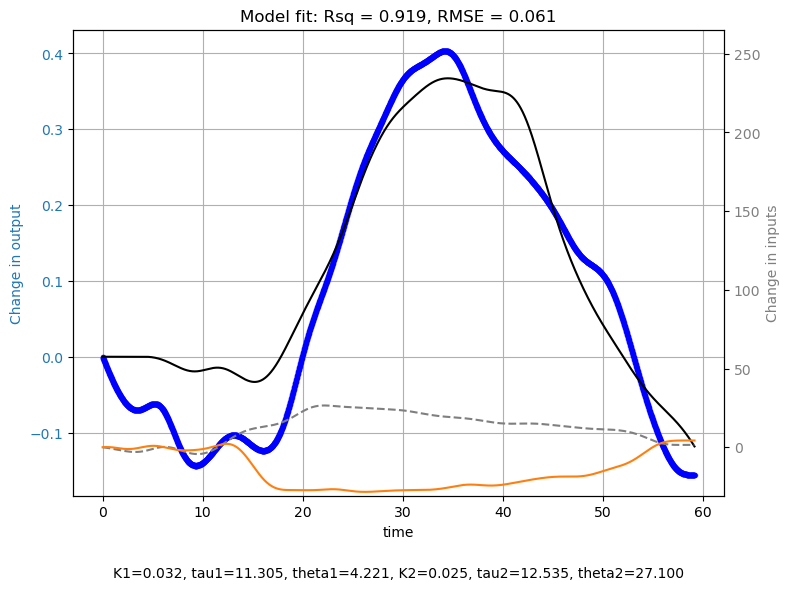

In [21]:
fom = FOPDT(t, cleaned_cnear_O2hb, MAP, HR)
result = fom.fit_model(plot_result=True)

In [ ]:
result.p_opt ## (K1, tau1, theta1, K2, tau2, theta2)

array([3.17364324e-02, 1.13050217e+01, 4.22134280e+00, 2.47463088e-02,
       1.25352059e+01, 2.71000000e+01])